# Chapter 11 - Modelling a synthetic time series with CNN

In [9]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Subset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import sys
sys.path.append('../')
from Chapter10.utils import *
from Chapter10.models import TimeSeriesCNN1D, TimeSeriesMultilayerCNN1D, train, predict, neural_architecture_search

## Data
### Create dummy time series

In [5]:
time = np.arange(4 * 365 + 1, dtype="float32")
series = trend(time, 0.1)
baseline = 10
amplitude = 20
slope = 0.09
noise_level = 5

series = baseline + trend(time, slope)
series += seasonality(time, period=365, amplitude=amplitude)
series += noise(time, noise_level, seed=42)

### Create samples

In [6]:
window_size = 30

series_tensor = torch.tensor(series, dtype=torch.float32)
features, targets = create_sliding_windows(series_tensor, window_size, shift=1)

### `DataLoader`

Turn this data into a dataset, and split it into trainng and validation slices.

Original series length: 1461
Total number of windows: 1432
Training windows: 971
Validation windows: 461

Example Training Batch:
Batch shape - Features: torch.Size([32, 29]), Targets: torch.Size([32, 1])

Example Validation Batch:
Batch shape - Features: torch.Size([32, 29]), Targets: torch.Size([32, 1])


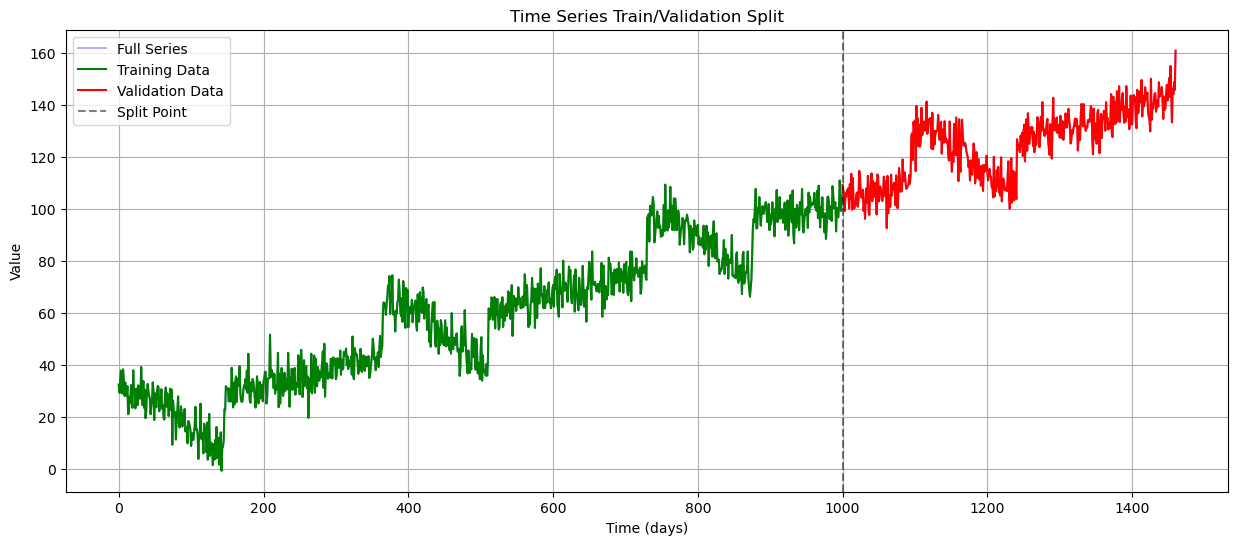

In [ ]:
split_location = 1000
batch_size = 32

# Create the full dataset
full_dataset = TensorDataset(features, targets)

# Calculate split indices
# Note: Since we're using windows, we need to account for the overlap
# The index 1000 in the original series will correspond to a different window index
train_size = split_location - window_size + 1  # Adjust for window overlap
total_windows = len(full_dataset)
train_indices = list(range(train_size))
val_indices = list(range(train_size, total_windows))

# Create training and validation datasets using Subset
train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Print information about the splits
print(f"Original series length: {len(series)}")
print(f"Total number of windows: {total_windows}")
print(f"Training windows: {len(train_dataset)}")
print(f"Validation windows: {len(val_dataset)}")

# Show example batch from each
print("\nExample Training Batch:")
train_features, train_targets = next(iter(train_loader))
print(f"Batch shape - Features: {train_features.shape}, Targets: {train_targets.shape}")

print("\nExample Validation Batch:")
val_features, val_targets = next(iter(val_loader))
print(f"Batch shape - Features: {val_features.shape}, Targets: {val_targets.shape}")

# Visualize the split point
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(range(len(series)), series, 'b-', label='Full Series', alpha=0.3)
plt.plot(range(1000), series[:1000], 'g-', label='Training Data')
plt.plot(range(1000, len(series)), series[1000:], 'r-', label='Validation Data')
plt.axvline(x=1000, color='k', linestyle='--', alpha=0.5, label='Split Point')
plt.title('Time Series Train/Validation Split')
plt.xlabel('Time (days)')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Model

### 1-layered CNN

Train loader batch shape:
Features shape: torch.Size([32, 29])
Targets shape: torch.Size([32, 1])
Using input size: 29
Epoch [100 / 1000], Train Loss: 4238.5739, Val Loss: 15831.5742
Epoch [200 / 1000], Train Loss: 4210.6698, Val Loss: 15754.4969
Epoch [300 / 1000], Train Loss: 4239.1361, Val Loss: 15677.6063
Epoch [400 / 1000], Train Loss: 4129.3941, Val Loss: 15600.9474
Epoch [500 / 1000], Train Loss: 4095.7078, Val Loss: 15524.4777
Epoch [600 / 1000], Train Loss: 4110.4052, Val Loss: 15448.2003
Epoch [700 / 1000], Train Loss: 4040.0712, Val Loss: 15372.0923
Epoch [800 / 1000], Train Loss: 4001.8553, Val Loss: 15296.2077
Epoch [900 / 1000], Train Loss: 3948.8836, Val Loss: 15220.5141
Epoch [1000 / 1000], Train Loss: 3943.6964, Val Loss: 15145.0038


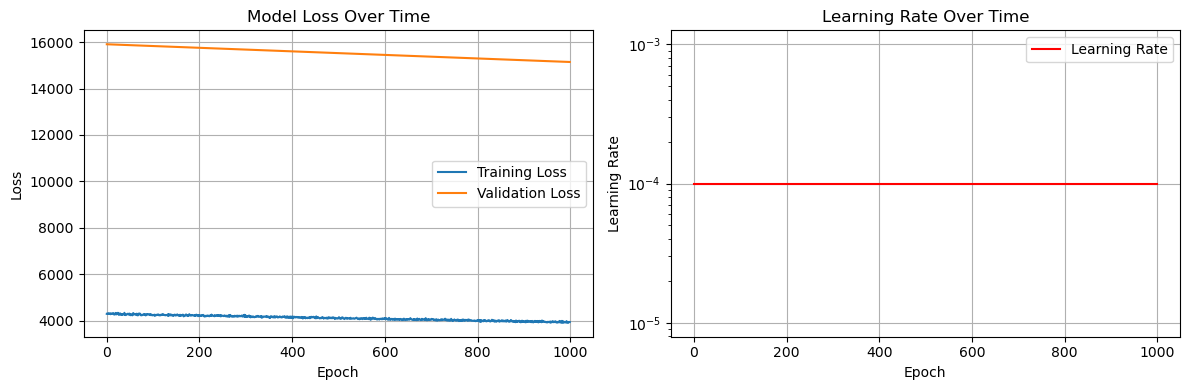

Train predictions shape: torch.Size([971, 1])
Validation predictions shape: torch.Size([461, 1])


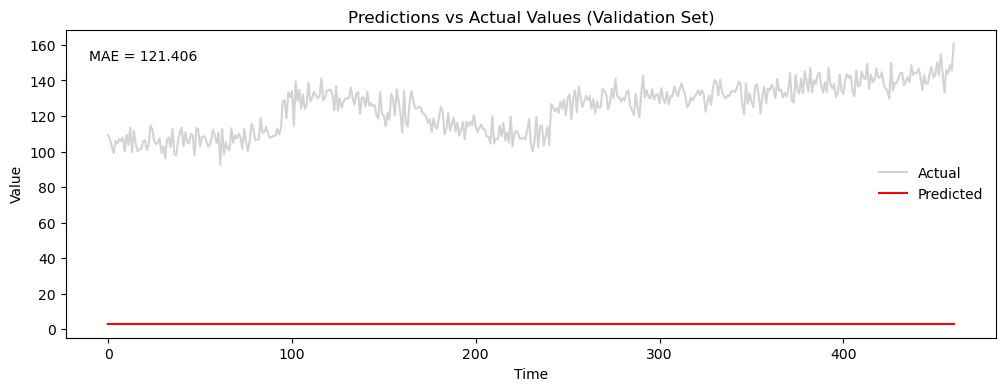

In [ ]:
if __name__ == "__main__":
    # Debug prints
    print("Train loader batch shape:")
    sample_batch = next(iter(train_loader))
    print("Features shape:", sample_batch[0].shape)
    print("Targets shape:", sample_batch[1].shape)

    # Initialize model with sequence length
    input_size = sample_batch[0].shape[1]  # Get sequence length from data
    print(f"Using input size: {input_size}")
    model = TimeSeriesCNN1D(input_size).to(device)

    # Train the model
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    model, loss, history = train(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        epochs=1000, 
        patience=20
        )
    plot_training(history['train_loss'], history['val_loss'], history['learning_rates'])

    # Prediction
    train_predictions, _ = predict(model, train_loader)
    print("Train predictions shape:\t", train_predictions.shape)
    val_predictions, val_targets = predict(model, val_loader)
    print("Validation predictions shape:\t", val_predictions.shape)
    plot_prediction(val_predictions, val_targets)

### Multi-layered CNN

#### Neural Architecture Search

> **Note:** Needs steps 1, 2, and 3 pre-run, as well as the 'evaluate_predictions' function in step 5 to be executed

In [11]:
def display_nas_results(results, total_time):
    """Display the results of the neural architecture search"""
    print("\nNeural Architecture Search Results")
    print(f"Total search time: {total_time:.2f} seconds")
    print("\nTop 5 Configurations:")

    for i, config in enumerate(results[:5]):
        print(f"\n{i+1}. Configuration:")
        print(f"   Number of Conv Layers: {config['num_conv_layers']}")
        print(f"   Conv Channels: {config['conv_channels']}")
        print(f"   Kernel Size: {config['kernel_size']}")
        print(f"   Dense Sizes: {config['dense_sizes']}")
        print(f"   Learning Rate: {config['learning_rate']}")
        print(f"   Validation MAE: {config['val_mae']:.4f}")
        print(f"   Validation Loss: {config['val_loss']:.4f}")

Using device: cuda
Total configurations to try: 48

Trying configuration 1/48:
{'num_conv_layers': 1, 'conv_channels': [32], 'kernel_size': 3, 'dense_sizes': [16], 'learning_rate': 0.001}
Model architecture:
Input size: 29
Conv channels: [32]
Flattened size: 928
Dense sizes: [16]
Early stopping tiggered after 18 epochs
New best MAE: 4.4966

Trying configuration 2/48:
{'num_conv_layers': 1, 'conv_channels': [32], 'kernel_size': 3, 'dense_sizes': [16], 'learning_rate': 0.0001}
Model architecture:
Input size: 29
Conv channels: [32]
Flattened size: 928
Dense sizes: [16]
Epoch [100 / 100], Train Loss: 33.2771, Val Loss: 34.8325

Trying configuration 3/48:
{'num_conv_layers': 1, 'conv_channels': [32], 'kernel_size': 3, 'dense_sizes': [32, 16], 'learning_rate': 0.001}
Model architecture:
Input size: 29
Conv channels: [32]
Flattened size: 928
Dense sizes: [32, 16]
Early stopping tiggered after 45 epochs

Trying configuration 4/48:
{'num_conv_layers': 1, 'conv_channels': [32], 'kernel_size': 3,

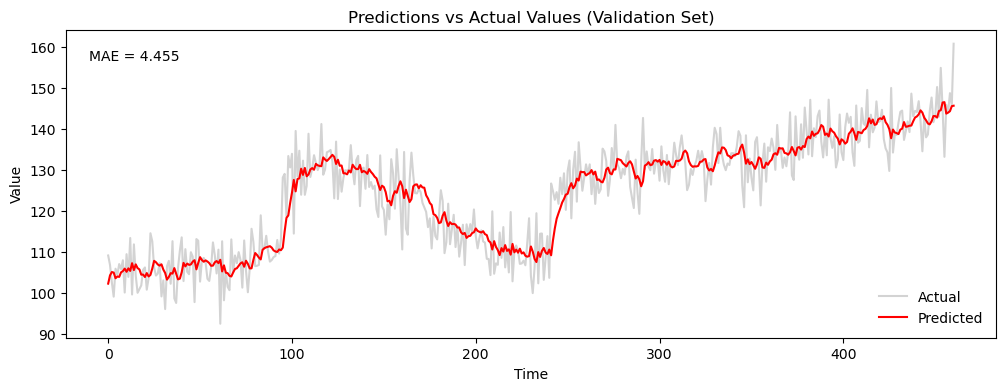

In [12]:
# Run the search
best_model, results, total_time = neural_architecture_search(train_loader, val_loader)

# Display results
display_nas_results(results, total_time)

# Generate and plot predictions with the best model
val_predictions, val_targets = predict(best_model, val_loader)
plot_prediction(val_predictions, val_targets)

#### Train best architecture

Train loader batch shape:
Features shape: torch.Size([32, 29])
Targets shape: torch.Size([32, 1])
Using input size: 29
Model architecture:
Input size: 29
Conv channels: [64, 32]
Flattened size: 928
Dense sizes: [32, 16]
Early stopping tiggered after 81 epochs


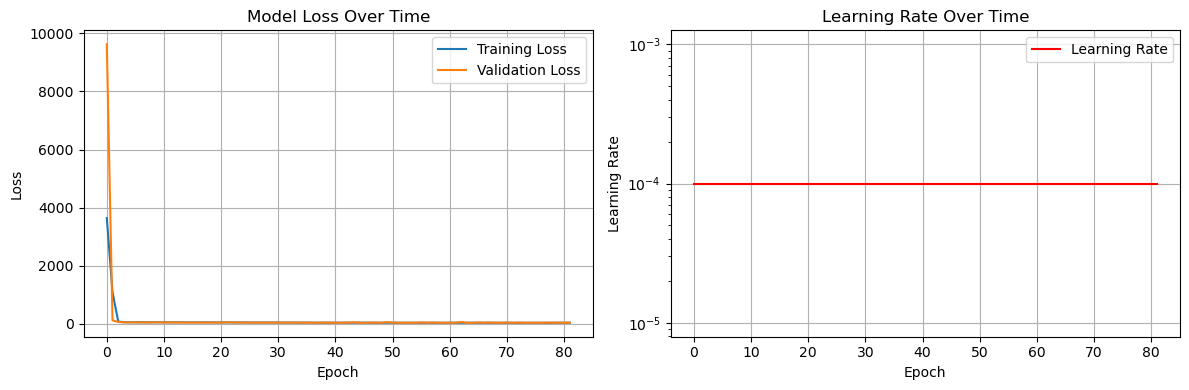

Train predictions shape: torch.Size([971, 1])
Validation predictions shape: torch.Size([461, 1])


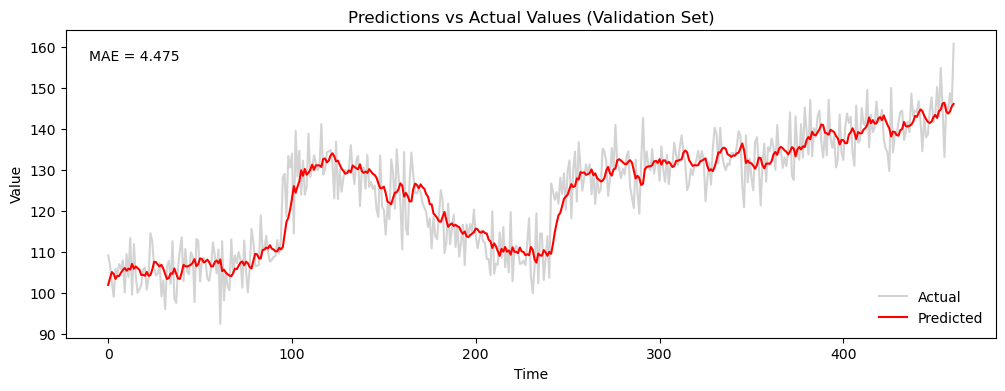

In [13]:
if __name__ == "__main__":
    # Debug prints
    print("Train loader batch shape:")
    sample_batch = next(iter(train_loader))
    print("Features shape:", sample_batch[0].shape)
    print("Targets shape:", sample_batch[1].shape)

    # Initialize model with sequence length
    input_size = sample_batch[0].shape[1]  # Get sequence length from data
    print(f"Using input size: {input_size}")
    config = results[0]
    model = TimeSeriesMultilayerCNN1D(
        input_size=input_size,
        num_conv_layers=config['num_conv_layers'],
        conv_channels=config['conv_channels'],
        kernel_size=config['kernel_size'],
        dense_sizes=config['dense_sizes']
        ).to(device)

    # Train the model
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
    model, loss, history = train(
        model, 
        train_loader,
        val_loader, 
        criterion, 
        optimizer, 
        epochs=1000, 
        patience=20
        )
    plot_training(history['train_loss'], history['val_loss'], history['learning_rates'])
    
    # Prediction
    train_predictions, train_targets = predict(model, train_loader)
    val_predictions, val_targets = predict(model, val_loader)
    print("Train predictions shape:", train_predictions.shape)
    print("Validation predictions shape:", val_predictions.shape)
    plot_prediction(val_predictions, val_targets)